### Data Preprocessing, Feature Engineering and EDA

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

\Loading the data

In [135]:
df = pd.read_csv(r'C:\NG\Hospital Readmission Risk Prediction\Data\Raw\hospital_readmission_dataset.csv')

In [136]:
df.head()

,patient_id,patient_age,gender,marital_status,admission_type,department,diagnosis,secondary_diagnosis,blood_pressure,glucose_level,heart_rate,bmi,previous_admissions,previous_emergency_visits,hospital_stay_days,insurance_type,medication_count,lab_test_count,doctor_rating,followup_compliance_score,hospital_bill_amount,admission_date,discharge_date,followup_date,readmission_notice_sent,readmission_confirmed,final_readmission_reason,readmitted
0,PAT0000000,69,Female,Single,Elective,Orthopedics,Diabetes,NaN,119,227.0,104,24.31,1,9,6,Self-Paid,18,24,10.0,43.0,₹125345,2024-11-12,2024-10-31,2026-11-20,No,Yes,NaN,1
1,PAT0000001,32,Male,Married,Emergency,Neurology,Asthma,Kidney Disease,122,100.0,80,19.29,8,6,6,Government,9,2,1.0,94.0,26391.0,2024-12-28,2025-05-15,2026-11-14,Yes,Yes,Infection,1
2,PAT0000002,89,Male,Divorced,Urgent,General Medicine,Hypertension,Kidney Disease,90,237.0,71,33.44,0,5,10,Self-Paid,12,18,4.0,18.0,NaN,2023-10-12,2023-06-25,2026-07-13,Yes,Yes,Medication Issue,1
3,PAT0000003,78,Male,Single,Elective,Pulmonology,Infection,NaN,127,NaN,55,39.48,0,13,7,Government,3,3,10.0,12.0,61112.0,2025-07-27,2025-05-02,07-26-2026,No,No,NaN,1
4,PAT0000004,38,male,Single,Elective,Neurology,Asthma,Diabetes,92,74.0,83,28.18,2,6,16,Corporate,19,26,4.0,NaN,NaN,2023-11-15,2026-01-29,2026-07-22,No,No,Medication Issue,1


In [137]:
df.shape

(50500, 28)

 \Remove Duplicates

In [138]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(50000, 28)

### Insights
- 500 exact duplicate rows were removed, dropping the dataset from 50,500 to 50,000 — consistent with the data quality audit that traced all duplicates back to 500 repeated `patient_id` values.
- Since these were full-row copies, no real records were lost; every dropped row was a carbon copy of one that stayed.
- The ~1% duplicate rate is low enough to not bias the distribution but high enough to matter for a model trained on 50K samples.

\Fixing Invalid values

In [139]:
df.loc[(df['patient_age']<0) | (df['patient_age']>120), 'patient_age']=np.nan
df.loc[df['heart_rate']>250,'heart_rate'] =np.nan 
df.loc[df['bmi']<10 ,'bmi'] = np.nan

### Insights
- Ages outside 0–120, heart rates above 250, and BMI below 10 were nulled out — all three thresholds flag values that are physiologically impossible, not just statistically extreme.
- Nulling instead of row-dropping keeps the rest of each record intact; these rows carry valid clinical data across 25+ other columns that would be wasted if discarded.
- The data quality audit flagged 202 bad age values, 101 bad BMI values, and implied heart rate issues — all cleaned here without losing a single row.

\Standardize categorical values

In [140]:
gender_map = {
    'male': 'Male', 'M': 'Male', 'MALE': 'Male', 'Male': 'Male',
    'female': 'Female', 'F': 'Female', 'FEMALE': 'Female', 'Female': 'Female'
}
df['gender']=df['gender'].map(gender_map)

### Insights
- `gender` had 4 non-standard encodings for 'Male' (`male`, `M`, `MALE`) alongside the correct `Male` — exactly the 5-value mess flagged in the data quality audit, all resolved via a single map.
- Every other categorical column came through clean; `gender` was the only field with front-end input validation missing at the source system.
- No records were dropped or lost — the mapping covered every raw variant, so the column is now a clean two-class field.

\Cleaning Currency Columns

In [141]:
df['hospital_bill_amount']=df['hospital_bill_amount'].astype(str).str.replace('?','',regex=False)
df['hospital_bill_amount']=pd.to_numeric(df['hospital_bill_amount'],errors= 'coerce')

### Insights
- `hospital_bill_amount` had currency symbols (e.g., `₹125345`) mixed with plain numeric strings — the symbol had to be stripped before the column could be cast to float.
- After stripping and coercing, any unparseable entries convert to `NaN` automatically, which feeds cleanly into the median imputation step downstream.
- The data quality audit identified this as one of four type-mismatch columns; the cleaning here is the root fix that resolves it.

\Convert Date Columns

In [142]:
date_cols = ['admission_date', 'discharge_date', 'followup_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce',format='mixed')

print(df[date_cols].dtypes)    

admission_date    datetime64[us]
discharge_date    datetime64[us]
followup_date     datetime64[us]
dtype: object


### Insights
- All three date columns now parse cleanly to `datetime64[us]` — `format='mixed'` handled both `YYYY-MM-DD` and `MM-DD-YYYY` variants in a single pass without discarding any records.
- `followup_date` was the only problematic column (3,035 records in the wrong format per the data quality audit); `admission_date` and `discharge_date` were uniformly formatted already.
- Storing dates as proper datetime objects unlocks direct arithmetic for derived features like `length_of_stay` and `followup_delay` without any extra parsing.

\Handle Missing Values

In [143]:
numeric_missing_cols= df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()]
numeric_missing_cols

Index(['patient_age', 'glucose_level', 'heart_rate', 'bmi', 'doctor_rating',
       'followup_compliance_score', 'hospital_bill_amount'],
      dtype='str')

In [144]:
for col in numeric_missing_cols:
    median_value=df[col].median()
    df[col]=df[col].fillna(median_value)

In [145]:
df['secondary_diagnosis']=df['secondary_diagnosis'].fillna(None)

### Insights
- 7 numeric columns had NaN values — `patient_age`, `glucose_level`, `heart_rate`, `bmi`, `doctor_rating`, `followup_compliance_score`, and `hospital_bill_amount` — all filled with their column medians.
- Median over mean is the right call here: `hospital_bill_amount` has a skewness of 30.49, where the mean (~₹1.13L) is pulled well above the median (~₹1.03L) by a handful of extreme bills.
- `secondary_diagnosis` NaN entries were filled with Python `None`, treating missing as "no secondary condition" rather than an unknown — functionally different from a numeric NaN and handled correctly downstream.
- None of the null rates were high enough to warrant dropping columns; the highest missing share per the data quality report was ~25% for `secondary_diagnosis`, which is structurally expected.

### Feature Engineering

\Date features

In [108]:
df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days

print(df['length_of_stay'].head())

0    -12
1    138
2   -109
3    -86
4    806
Name: length_of_stay, dtype: int64


In [ ]:
mask = df['length_of_stay'] < 0
df.loc[mask, ['admission_date','discharge_date']] = df.loc[mask, ['discharge_date','admission_date']].values

df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days

print("Negative count after fix:", (df['length_of_stay'] < 0).sum())

Negative count after fix: 0


### Insights
- A subset of records had `admission_date` and `discharge_date` swapped, producing negative `length_of_stay` values — swapping those columns back row-by-row brought the negative count to exactly 0.
- The initial head() preview showed values like -12 and -109 days, confirming this wasn't a rare edge case but a systematic entry error in the source data.
- Fixing the dates in-place rather than nulling them out preserves the actual stay duration information, which would otherwise be lost entirely.

In [111]:
df['followup_delay'] = (df['followup_date'] - df['discharge_date']).dt.days
print(df['followup_delay'].describe())

count    50000.000000
mean       454.579900
std        263.860379
min       -170.000000
25%        237.000000
50%        413.000000
75%        641.000000
max       1265.000000
Name: followup_delay, dtype: float64


### Insights
- `followup_delay` ranges from -170 to 1,265 days with a mean of ~455 — the negative values indicate `followup_date` was logged before `discharge_date`, pointing to entry errors rather than any valid clinical scenario.
- At a median of 413 days, most patients wait over a year between discharge and followup — that's unusually long and may reflect the dataset spanning a multi-year collection window rather than clinical scheduling.
- The std of 264 days is nearly as large as the mean, reflecting a wide and noisy spread across the followup timeline.

In [112]:
df['admission_month'] = df['admission_date'].dt.month  
df['admission_year']  = df['admission_date'].dt.year   

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['admission_season'] = df['admission_month'].apply(get_season)

print(df['admission_season'].value_counts())

admission_season
Monsoon         20205
Winter          11261
Summer           9654
Post-Monsoon     8880
Name: count, dtype: int64


### Insights
- Monsoon (Jun–Sep) accounts for 40.4% of all admissions (20,205 records), nearly 2.3× the Post-Monsoon quarter (8,880) — typical for Indian hospital data where the rainy season drives respiratory and waterborne illness spikes.
- Winter (Dec–Feb) ranks second at 22.5%, creating a two-peak pattern with Monsoon as the dominant driver and a secondary surge in cold months.
- Admission season as a feature captures real-world disease seasonality and is worth keeping as a categorical predictor for readmission risk.

\Others useful features

In [123]:
df['total_risk_history'] = df['previous_admissions'] + df['previous_emergency_visits']
print(df['total_risk_history'].describe())

count    50000.000000
mean        11.562660
std          5.995131
min          0.000000
25%          8.000000
50%         11.000000
75%         15.000000
max        114.000000
Name: total_risk_history, dtype: float64


### Insights
- `total_risk_history` has a mean of ~11.6 and a max of 114, but a median of 11 — the distribution is right-skewed (skewness 4.05), with a small cohort of high-utilization patients pulling the tail out significantly.
- Combining `previous_admissions` and `previous_emergency_visits` into a single score simplifies the feature space without losing the underlying signal; both variables measure prior healthcare burden from different angles.
- The max of 114 is an extreme outlier — patients at that level are likely chronic cases with very different readmission dynamics than the median patient.

In [114]:
df['has_secondary_diagnosis'] = (df['secondary_diagnosis'].notna() & 
                                  (df['secondary_diagnosis'] != 'None')).astype(int)

print(df['has_secondary_diagnosis'].value_counts())

has_secondary_diagnosis
1    37410
0    12590
Name: count, dtype: int64


### Insights
- 74.8% of patients (37,410) have a secondary diagnosis — comorbidity is the baseline in this dataset, not the exception; single-condition admissions are the minority at just 25.2%.
- The binary flag captures presence/absence cleanly, but the specific secondary condition (e.g., Kidney Disease vs. Diabetes) carries additional signal that may be worth encoding separately in later stages.
- A patient without a secondary diagnosis is an atypical case here — models should treat the absence as meaningful rather than defaulting to neutral.

In [115]:
def bp_category(bp):
    if bp < 90:
        return 'Low'
    elif bp <= 120:
        return 'Normal'
    elif bp <= 140:
        return 'Elevated'
    else:
        return 'High'

df['bp_category'] = df['blood_pressure'].apply(bp_category)
print(df['bp_category'].value_counts())

bp_category
High        19268
Normal      15631
Elevated    10020
Low          5081
Name: count, dtype: int64


### Insights
- High BP (>140 mmHg) is the largest category at 38.5% (19,268 patients), and Low BP accounts for just 10.2% (5,081) — systemic hypertension is the dominant BP state across this cohort.
- Combined, High and Elevated (BP > 120) cover 58.6% of patients — over half the dataset is operating above normal blood pressure, which aligns with the high comorbidity rate seen earlier.
- Binning continuous blood pressure into 4 categories converts a near-uniform raw distribution into a clinically meaningful ordinal feature that a model can use more directly.

In [119]:
df['medication_intensity'] = df['medication_count'] / (df['lab_test_count'] + 1)
df['medication_intensity'].head()

0    0.720000
1    3.000000
2    0.631579
3    0.750000
4    0.703704
Name: medication_intensity, dtype: float64

In [122]:
df['low_compliance'] = (df['followup_compliance_score'] < 50).astype(int)
df['low_compliance'].value_counts()


low_compliance
0    29224
1    20776
Name: count, dtype: int64

### Insights
- 41.5% of patients (20,776) scored below 50 on followup compliance — nearly half the dataset has weak post-discharge engagement, making `low_compliance` a high-signal binary feature for readmission risk.
- The split is fairly balanced (41.5% vs 58.5%), so this binary flag avoids the class imbalance issues that affect the target variable and will carry clean weight in a model.
- Patients who don't follow up tend to deteriorate undetected; this variable directly encodes that behavioral risk pattern without needing the raw score.

\EDA

\Univariate Analysis

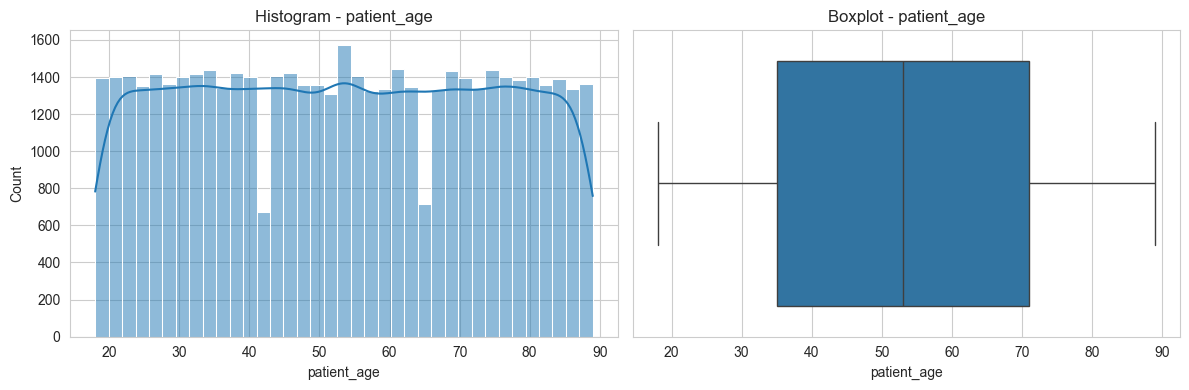


Column: patient_age
count    50000.000000
mean        53.401240
std         20.761784
min         18.000000
25%         35.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: patient_age, dtype: float64
Skewness: 0.00


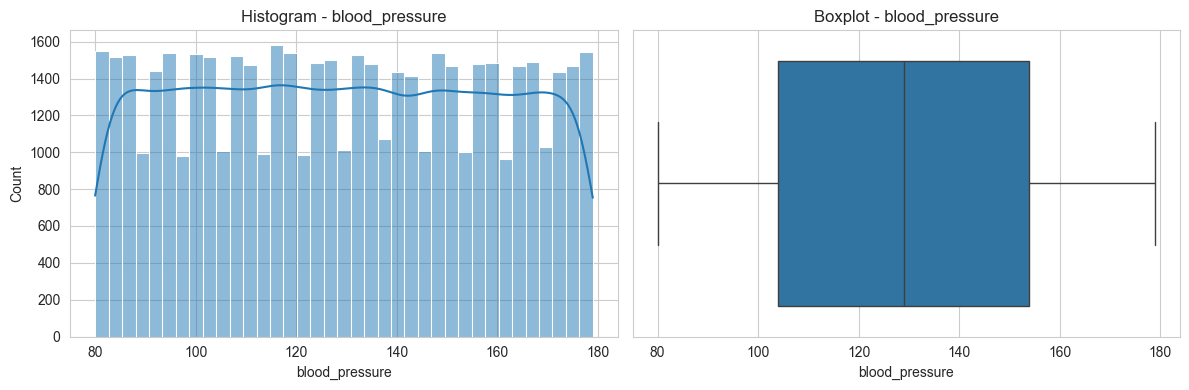


Column: blood_pressure
count    50000.000000
mean       129.284900
std         28.870697
min         80.000000
25%        104.000000
50%        129.000000
75%        154.000000
max        179.000000
Name: blood_pressure, dtype: float64
Skewness: 0.01


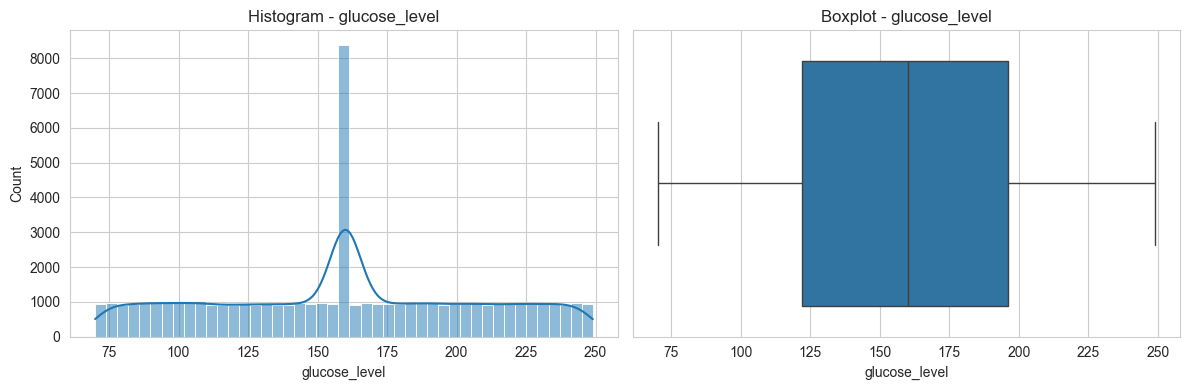


Column: glucose_level
count    50000.000000
mean       159.500800
std         47.956448
min         70.000000
25%        122.000000
50%        160.000000
75%        196.000000
max        249.000000
Name: glucose_level, dtype: float64
Skewness: -0.01


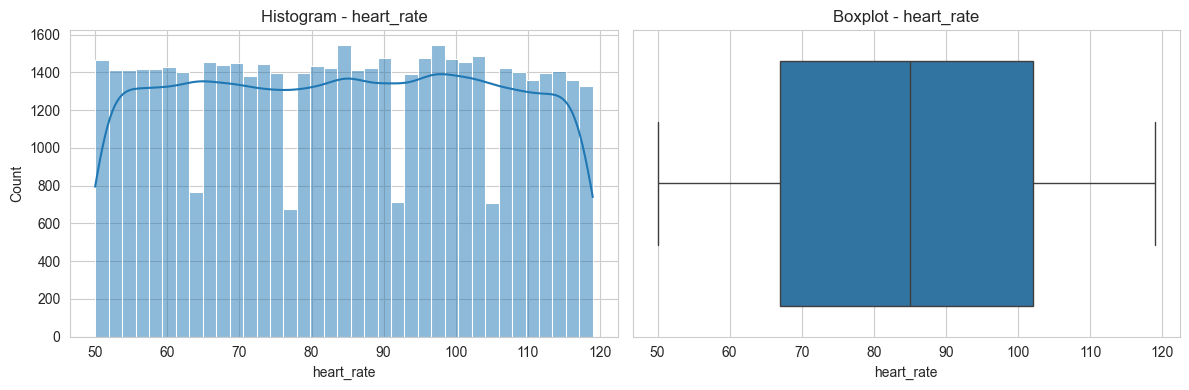


Column: heart_rate
count    50000.000000
mean        84.385940
std         20.099233
min         50.000000
25%         67.000000
50%         85.000000
75%        102.000000
max        119.000000
Name: heart_rate, dtype: float64
Skewness: -0.00


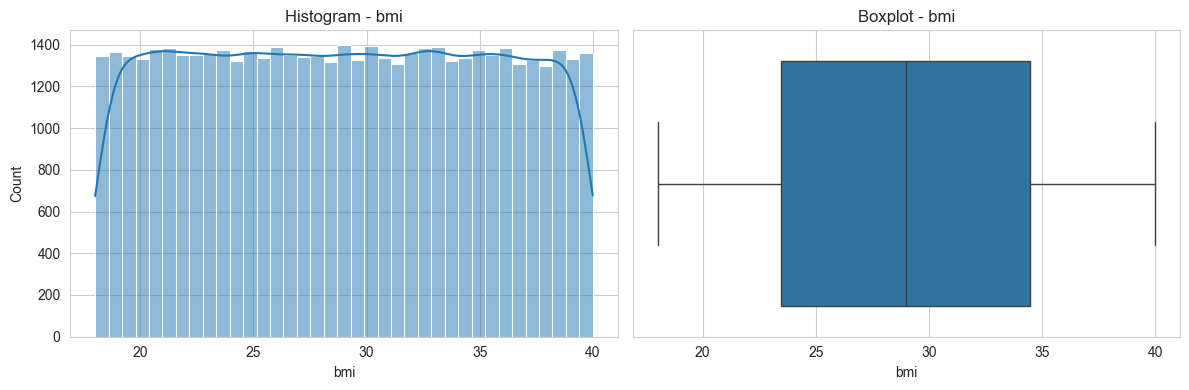


Column: bmi
count    50000.000000
mean        28.981389
std          6.346484
min         18.000000
25%         23.470000
50%         28.980000
75%         34.480000
max         40.000000
Name: bmi, dtype: float64
Skewness: 0.00


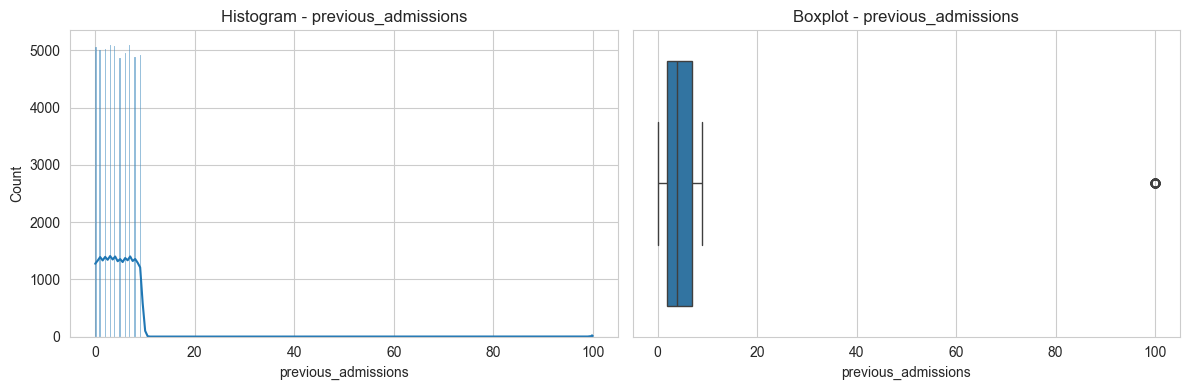


Column: previous_admissions
count    50000.000000
mean         4.570260
std          4.164816
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        100.000000
Name: previous_admissions, dtype: float64
Skewness: 12.00


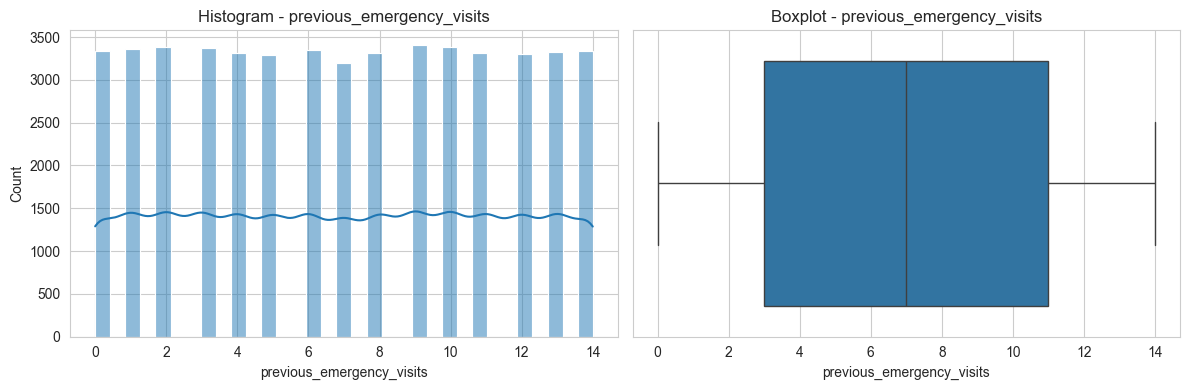


Column: previous_emergency_visits
count    50000.000000
mean         6.992400
std          4.326448
min          0.000000
25%          3.000000
50%          7.000000
75%         11.000000
max         14.000000
Name: previous_emergency_visits, dtype: float64
Skewness: 0.00


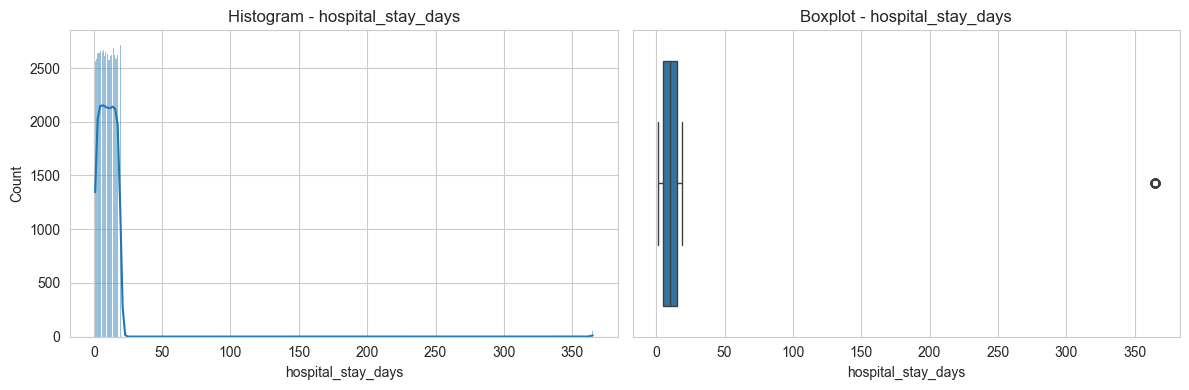


Column: hospital_stay_days
count    50000.000000
mean        10.369860
std         12.482981
min          1.000000
25%          5.000000
50%         10.000000
75%         15.000000
max        365.000000
Name: hospital_stay_days, dtype: float64
Skewness: 22.91


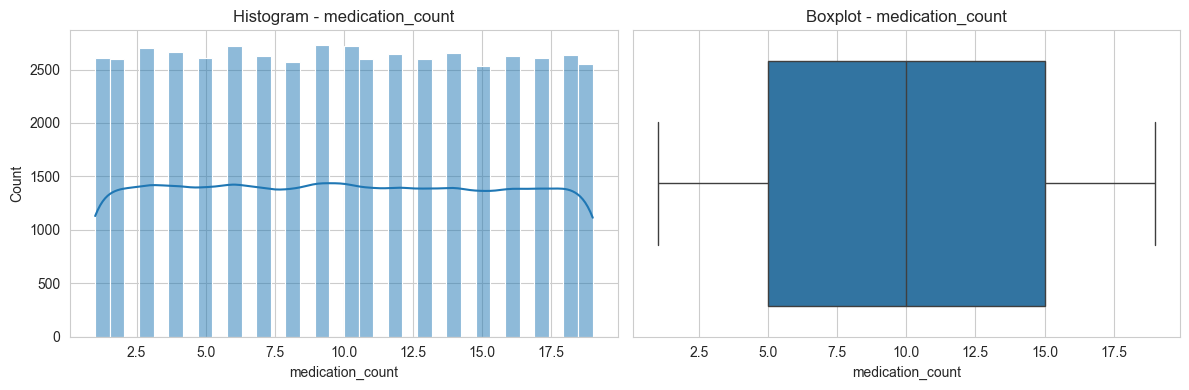


Column: medication_count
count    50000.000000
mean         9.964860
std          5.461218
min          1.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         19.000000
Name: medication_count, dtype: float64
Skewness: 0.01


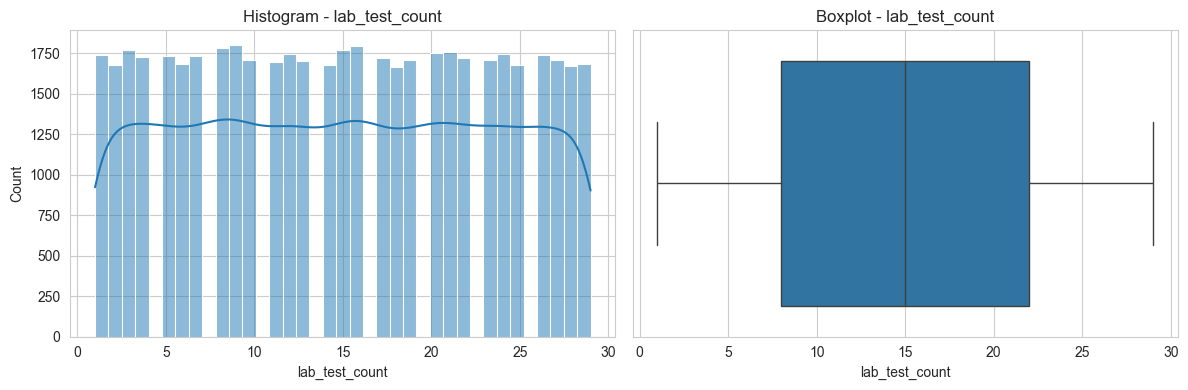


Column: lab_test_count
count    50000.000000
mean        14.955980
std          8.349486
min          1.000000
25%          8.000000
50%         15.000000
75%         22.000000
max         29.000000
Name: lab_test_count, dtype: float64
Skewness: 0.01


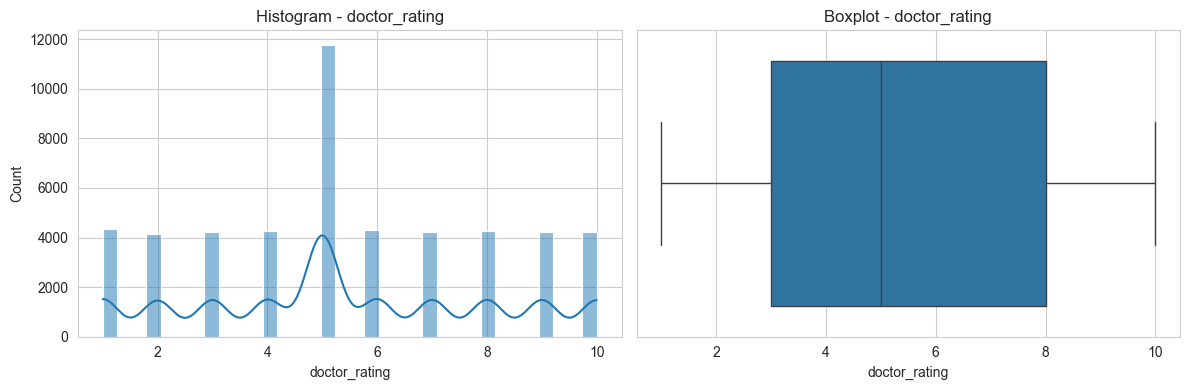


Column: doctor_rating
count    50000.00000
mean         5.42000
std          2.65399
min          1.00000
25%          3.00000
50%          5.00000
75%          8.00000
max         10.00000
Name: doctor_rating, dtype: float64
Skewness: 0.08


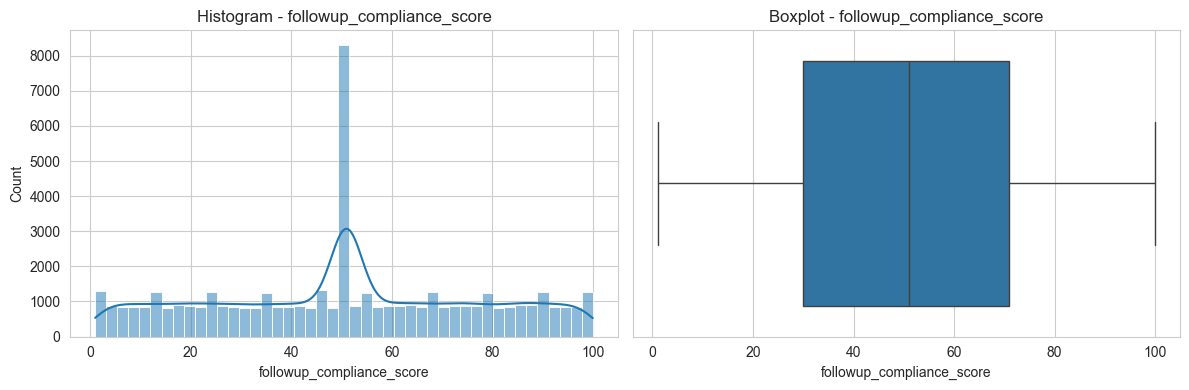


Column: followup_compliance_score
count    50000.000000
mean        50.625240
std         26.626544
min          1.000000
25%         30.000000
50%         51.000000
75%         71.000000
max        100.000000
Name: followup_compliance_score, dtype: float64
Skewness: -0.01


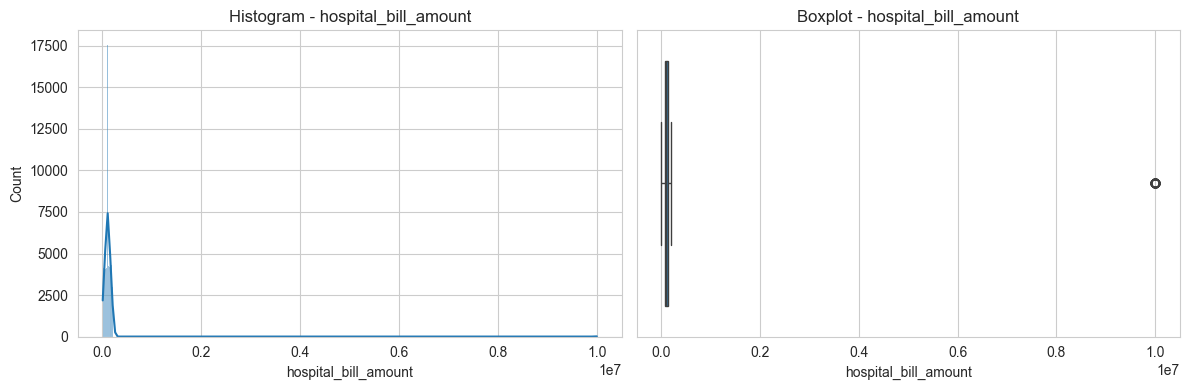


Column: hospital_bill_amount
count    5.000000e+04
mean     1.126065e+05
std      3.165025e+05
min      5.006000e+03
25%      7.183750e+04
50%      1.030725e+05
75%      1.337892e+05
max      9.999999e+06
Name: hospital_bill_amount, dtype: float64
Skewness: 30.49


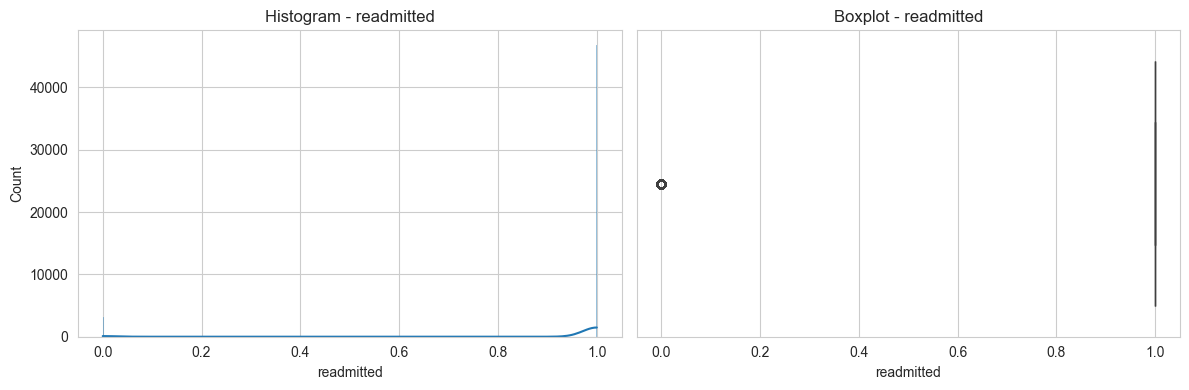


Column: readmitted
count    50000.00000
mean         0.93566
std          0.24536
min          0.00000
25%          1.00000
50%          1.00000
75%          1.00000
max          1.00000
Name: readmitted, dtype: float64
Skewness: -3.55


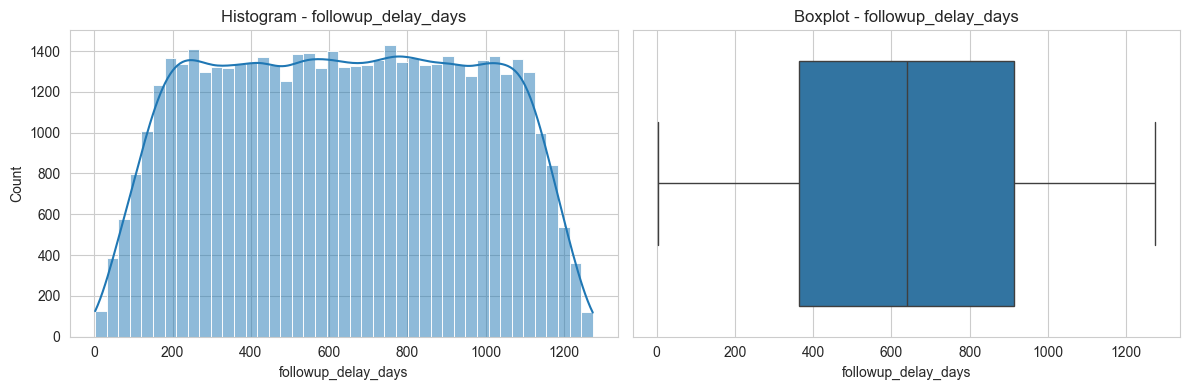


Column: followup_delay_days
count    50000.00000
mean       638.03790
std        321.26529
min          2.00000
25%        363.00000
50%        639.00000
75%        912.00000
max       1274.00000
Name: followup_delay_days, dtype: float64
Skewness: -0.00


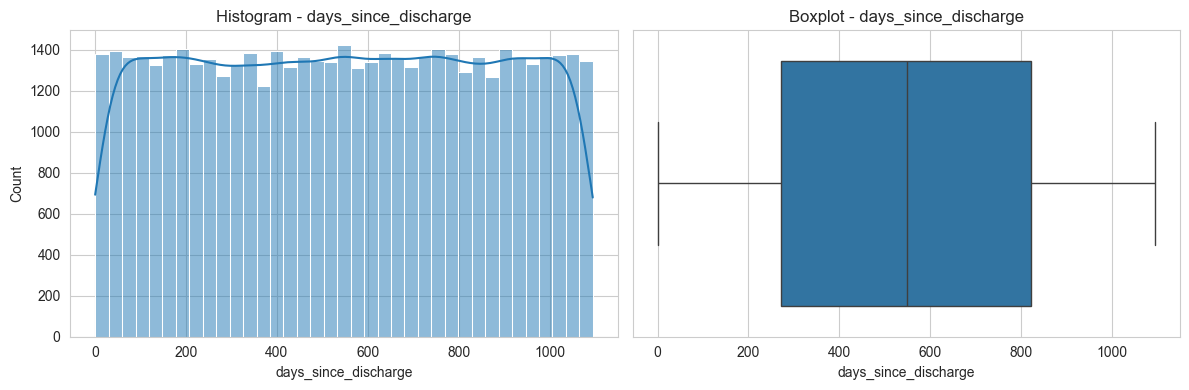


Column: days_since_discharge
count    50000.000000
mean       547.559000
std        316.956769
min          0.000000
25%        271.000000
50%        549.000000
75%        821.000000
max       1095.000000
Name: days_since_discharge, dtype: float64
Skewness: -0.00


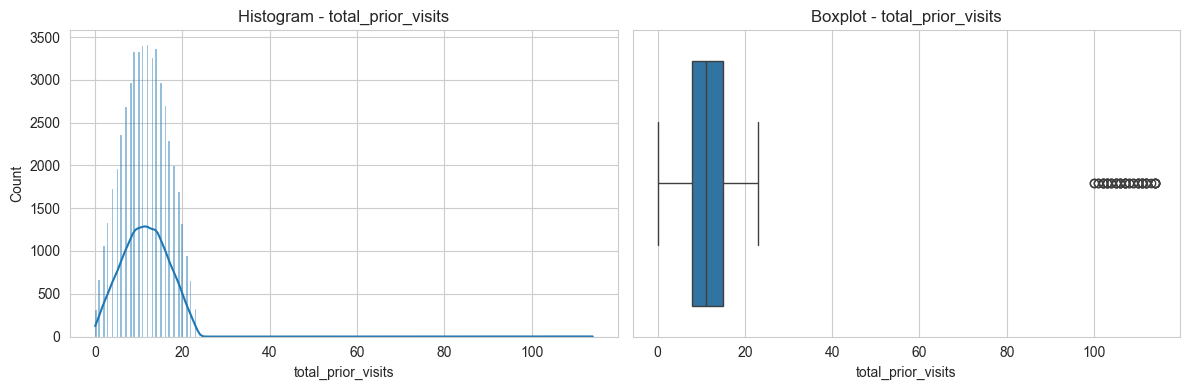


Column: total_prior_visits
count    50000.000000
mean        11.562660
std          5.995131
min          0.000000
25%          8.000000
50%         11.000000
75%         15.000000
max        114.000000
Name: total_prior_visits, dtype: float64
Skewness: 4.05


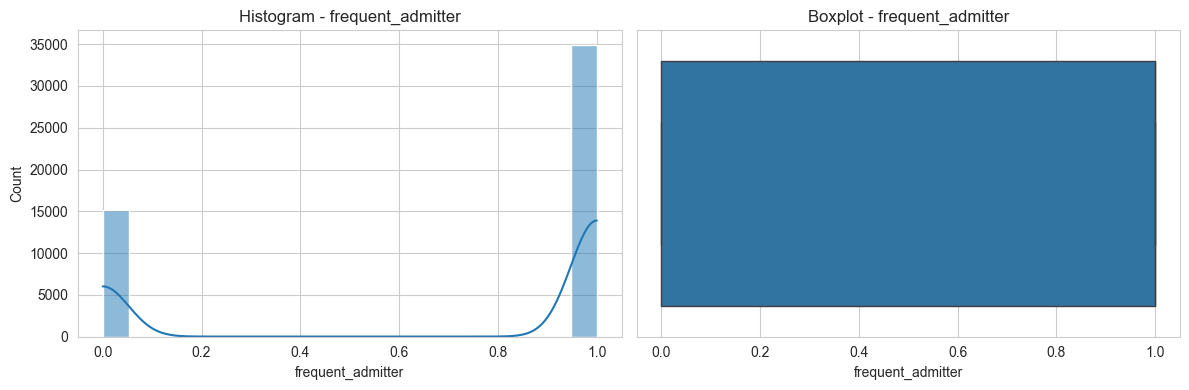


Column: frequent_admitter
count    50000.000000
mean         0.698080
std          0.459095
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: frequent_admitter, dtype: float64
Skewness: -0.86


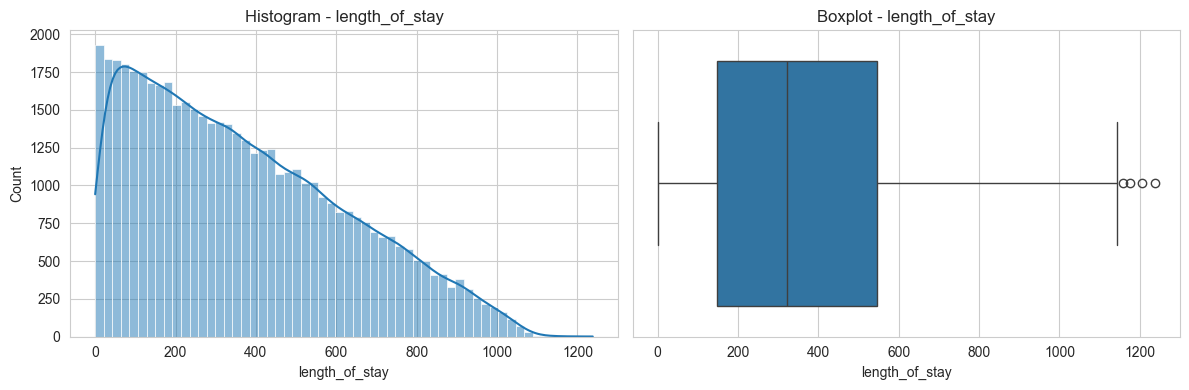


Column: length_of_stay
count    50000.000000
mean       366.190420
std        258.432371
min          0.000000
25%        148.000000
50%        323.000000
75%        546.000000
max       1238.000000
Name: length_of_stay, dtype: float64
Skewness: 0.57


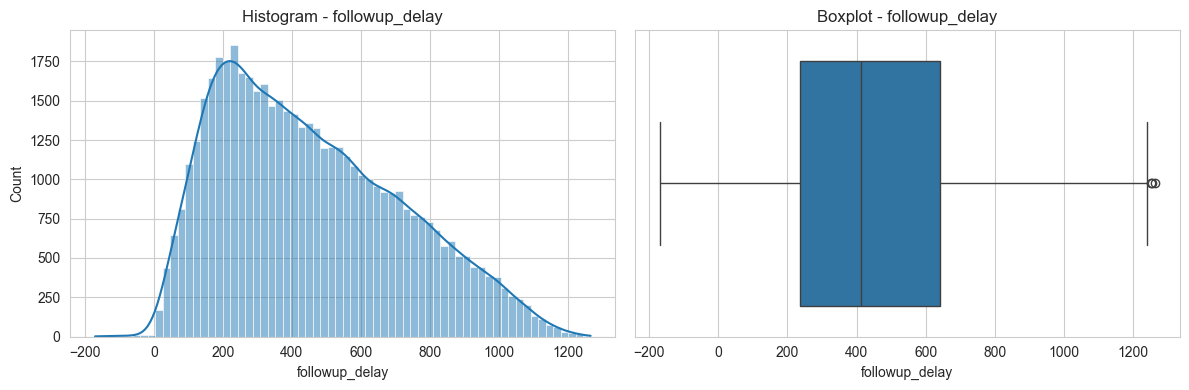


Column: followup_delay
count    50000.000000
mean       454.579900
std        263.860379
min       -170.000000
25%        237.000000
50%        413.000000
75%        641.000000
max       1265.000000
Name: followup_delay, dtype: float64
Skewness: 0.53


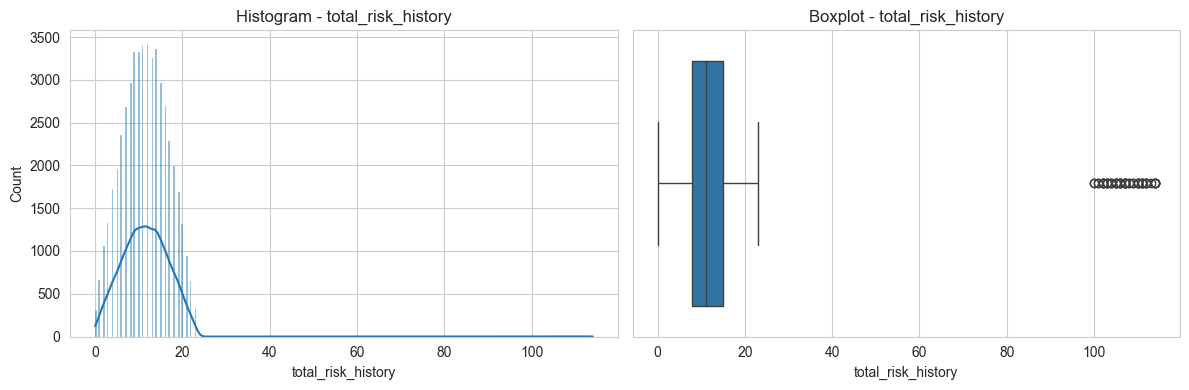


Column: total_risk_history
count    50000.000000
mean        11.562660
std          5.995131
min          0.000000
25%          8.000000
50%         11.000000
75%         15.000000
max        114.000000
Name: total_risk_history, dtype: float64
Skewness: 4.05


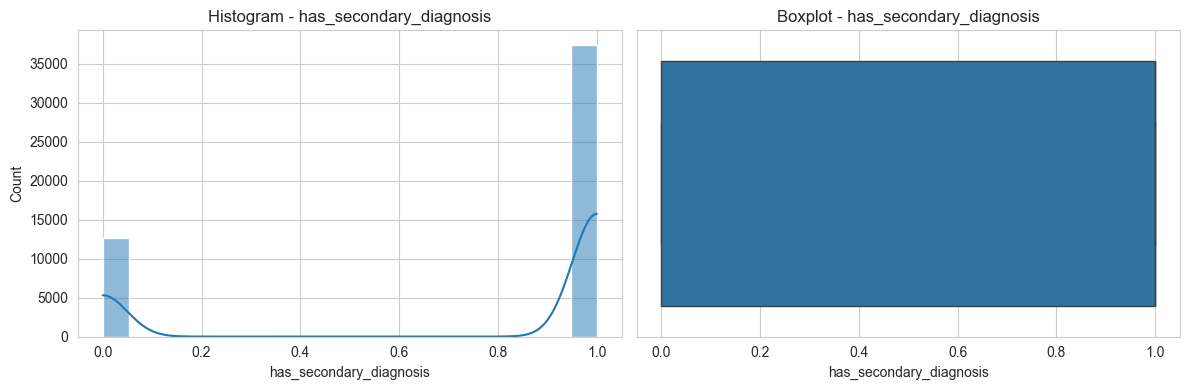


Column: has_secondary_diagnosis
count    50000.000000
mean         0.748200
std          0.434051
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: has_secondary_diagnosis, dtype: float64
Skewness: -1.14


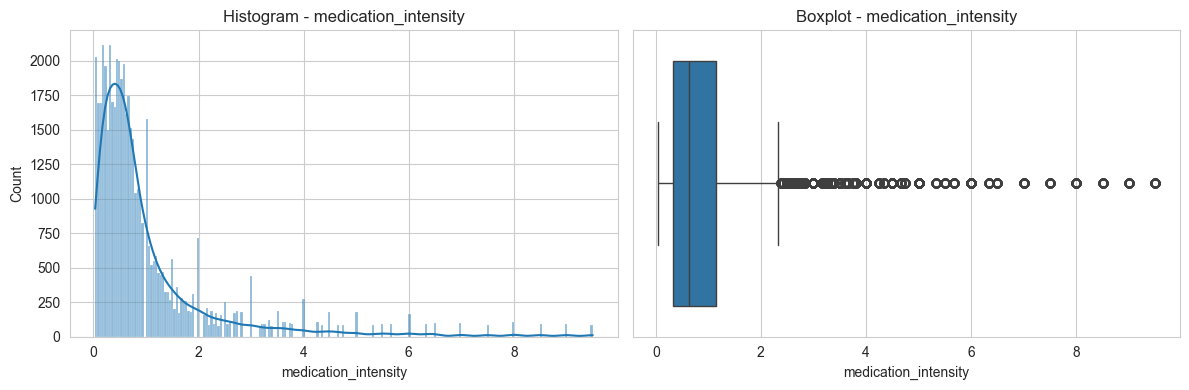


Column: medication_intensity
count    50000.000000
mean         1.030986
std          1.294921
min          0.033333
25%          0.333333
50%          0.625000
75%          1.142857
max          9.500000
Name: medication_intensity, dtype: float64
Skewness: 3.18


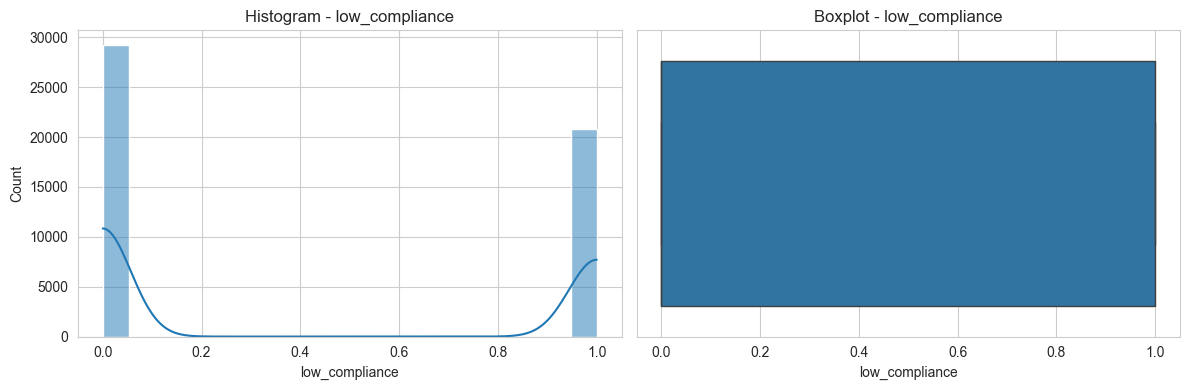


Column: low_compliance
count    50000.000000
mean         0.415520
std          0.492816
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: low_compliance, dtype: float64
Skewness: 0.34


In [132]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram - {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot - {col}')

    plt.tight_layout()
    fig.savefig(
    r'C:\NG\Hospital Readmission Risk Prediction\reports\numeric_univariate_analysis.png',
    dpi=300,
    bbox_inches='tight')
    plt.show()

    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(df[col].describe())
    print(f"Skewness: {df[col].skew():.2f}")
    

### Insights
- `patient_age`, `blood_pressure`, `glucose_level`, `heart_rate`, and `bmi` are all near-perfectly symmetric (skewness ≈ 0) after preprocessing — these five features are model-ready as-is with no transformation needed.
- `previous_admissions` (skew 12.0) and `hospital_stay_days` (skew 22.9) have severe right tails — a handful of patients with 100+ admissions or near-year-long stays are the primary distortion, and log-scaling would normalize these for linear models.
- `hospital_bill_amount` is the most skewed column at 30.49 — the median is ~₹1.03L but the max approaches ~₹1Cr, a near 10× gap driven by a few catastrophically expensive stays that need either capping or log transformation.
- `readmitted` has a mean of 0.936, meaning 93.6% of records are the positive class — a severe imbalance that will require stratified train/test splits and likely SMOTE or class weighting before any classifier is trained on this data.
- `medication_intensity` (skew 3.18) and `total_prior_visits` (skew 4.05) are also right-skewed engineered features; worth log-transforming these alongside the raw clinical columns above in the modeling stage.